## Empty wave flume multi-domain - Frequency-Domain BEM

**3D Boundary Element Method for Linear Wave Propagation**

This tutorial presents the implementation of a 3D BEM to simulate the propagation of regular linear water waves in an empty wave flume using a multi-domain approach.

The formulation is based on:
- Linear potential flow theory  
- Frequency-domain (time-harmonic) analysis  
- Boundary integral equation formulation  

Objectives of this notebook:
- Introduce the workflow and structure of the code  
- Solve the wave propagation problem in a multi-domain  
- Compute wave reflection and transmission coefficients

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

import meshio
import numpy as np

from BEM_UTILS.constants import gravity, rho

from BEM_UTILS.PROCESS_MESH import PROCESS_MESH
from BEM_UTILS.PROCESS_CONNECTIVITY import PROCESS_CONNECTIVITY
from BEM_UTILS.IDENTIFY_BOUNDARY_ELEMENTS import IDENTIFY_BOUNDARY_ELEMENTS
from BEM_UTILS.COS_DIR import COS_DIR

from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.TRILOC6 import TRILOC6
from MATRICES.FUNDA6 import FUNDA6

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_IN import BC_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.BC_FAR_FIELD_OUT import BC_FAR_FIELD_OUT
from BOUNDARY_CONDITIONS.BC_INTERFACE import BC_INTERFACE
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

from BEM_UTILS.MATCHING_INTERFACES import MATCHING_INTERFACES

from BEM_UTILS.FX_FUNCTION import FX_FUNCTION
from BEM_UTILS.ENERGY_FLUX import ENERGY_FLUX
from BEM_UTILS.NODES_FS import NODES_FS

from BEM_UTILS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

from BOUNDARY_CONDITIONS.FLUXES_FREE_SURFACE import FLUXES_FREE_SURFACE
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_IN import FLUXES_FAR_FIELD_IN
from BOUNDARY_CONDITIONS.FLUXES_FAR_FIELD_OUT import FLUXES_FAR_FIELD_OUT
from BOUNDARY_CONDITIONS.FLUXES_INTERFACE import FLUXES_INTERFACE
from BOUNDARY_CONDITIONS.POTENTIAL_INTERFACE import POTENTIAL_INTERFACE

from BEM_UTILS.INTERNAL_POINTS import INTERNAL_POINTS

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

**2.1 Physical domain and geometry parameters**

In [2]:
# Fluid domain
DEPTH = 0.40            # [m]
WIDTH_CHANNEL = 0.40 * DEPTH

# Numerical model
NUM_OF_REG = 3;

# Structure geometry
N_STRUCT = 1;

**2.2 Wave parameters and frequency range**

In [3]:
# Number of frequencies / wave cases
ttmax = 15

# Dimensionless wavenumber (k*h)
kh = np.linspace(0.005, 3.00, ttmax)

# Wave steepness H/λ
HL = 0.01

**3. Mesh**

In [4]:
# Read the Gmsh file and extract node coordinates and element connectivity
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("DOMAIN_0.msh")
MESH_1_POS, MESH_1_QUADS9 = PROCESS_MESH("DOMAIN_1.msh")
MESH_2_POS, MESH_2_QUADS9 = PROCESS_MESH("DOMAIN_2.msh")

In [5]:
# Quadrilateral elements are used; each element has 9 nodes ordered counterclockwise.
NCONEC = 9;

In [6]:
# Initialize arrays to store the number of nodes (N) and elements (NE) per region
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [7]:
# Extract the number of nodes, number of elements, and reorder element connectivity
# to match the node orientation required by the BEM formulation
N[0] ,  NE[0] ,  KCONEC_0 = PROCESS_CONNECTIVITY(MESH_0_POS , MESH_0_QUADS9)
N[1] ,  NE[1] ,  KCONEC_1 = PROCESS_CONNECTIVITY(MESH_1_POS , MESH_1_QUADS9)
N[2] ,  NE[2] ,  KCONEC_2 = PROCESS_CONNECTIVITY(MESH_2_POS , MESH_2_QUADS9)

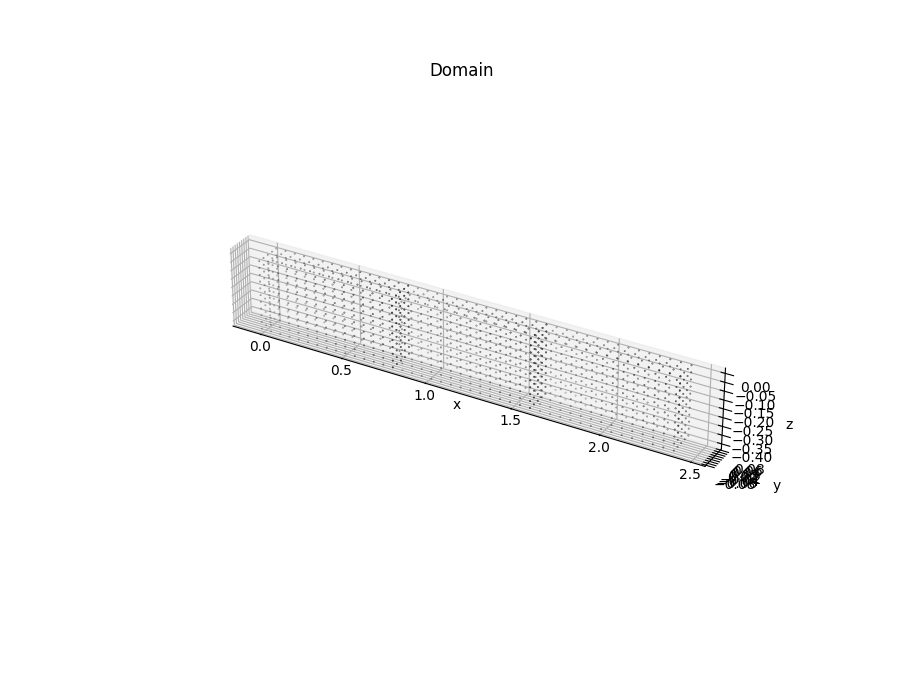

In [8]:
# Domain visulization
%matplotlib widget

fig = plt.figure(figsize=(9, 7)) # Interactive plots also respect figsize
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=0.1
)

ax.scatter(
    MESH_1_POS[:,0],
    MESH_1_POS[:,1],
    MESH_1_POS[:,2],
    c='k',
    s=0.1
)

ax.scatter(
    MESH_2_POS[:,0],
    MESH_2_POS[:,1],
    MESH_2_POS[:,2],
    c='k',
    s=0.1
)

# DOMAIN LIMITS
x_min, x_max = np.min(MESH_0_POS[:,0]), np.max(MESH_2_POS[:,0])
y_min, y_max = np.min(MESH_0_POS[:,1]), np.max(MESH_0_POS[:,1])
z_min, z_max = np.min(MESH_0_POS[:,2]), np.max(MESH_0_POS[:,2])

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Domain")

# Aspect ratio
ax.set_box_aspect([Lx, Ly, Lz])

plt.show()

In [9]:
# Identify elements belonging to each boundary and compute their outward normal vectors
REF_R0 , NORMAL_0 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_0 , MESH_0_POS , NE[0], N_STRUCT)
REF_R1 , NORMAL_1 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_1 , MESH_1_POS , NE[1], N_STRUCT)
REF_R2 , NORMAL_2 = IDENTIFY_BOUNDARY_ELEMENTS(NCONEC , KCONEC_2 , MESH_2_POS , NE[2], N_STRUCT)

In [10]:
# Concatenate normal array
NORMAL = np.vstack((NORMAL_0, NORMAL_1, NORMAL_2))

In [11]:
# Match central nodes (the 9th node) between adjacent regions to define the interface connectivity
# NODES_MATCH_R0_R1 = MATCHING(REF_R0['OUT'] ,  MESH_0_POS  ,  KCONEC_0  ,  REF_R1['IN'] ,  MESH_1_POS  ,  KCONEC_1);
# NODES_MATCH_R1_R2 = MATCHING(REF_R1['OUT'] ,  MESH_1_POS  ,  KCONEC_1  ,  REF_R2['IN'] ,  MESH_2_POS  ,  KCONEC_2);

[STORE_NODE_R0_out, STORE_NODE_R1_in] = MATCHING_INTERFACES(REF_R0['OUT'] , MESH_0_POS , KCONEC_0 , REF_R1['IN'] , MESH_1_POS , KCONEC_1 , NCONEC)
[STORE_NODE_R1_out, STORE_NODE_R2_in] = MATCHING_INTERFACES(REF_R1['OUT'] , MESH_1_POS , KCONEC_1 , REF_R2['IN'] , MESH_2_POS , KCONEC_2 , NCONEC)

In [12]:
# Total number of nodes and elements
N_total  = np.sum(N)
NE_total = np.sum(NE)

In [13]:
# Concatenate local connectivity matrices and map local node indices to the global coordinate system
KCON_N_0  = KCONEC_0
KCON_N_01 = KCONEC_1 + N[0]
KCON_N_02 = KCONEC_2 + N[0] + N[1]

KCONEC = np.hstack((KCON_N_0, KCON_N_01, KCON_N_02))

**4. Influence matrices**

In [14]:
# Form H and B matrices for each region
H0 , G0 = GHMAT6(MESH_0_POS , NCONEC , KCONEC_0 , NE[0] , N[0] , DEPTH);
H1 , G1 = GHMAT6(MESH_1_POS , NCONEC , KCONEC_1 , NE[1] , N[1] , DEPTH);
H2 , G2 = GHMAT6(MESH_2_POS , NCONEC , KCONEC_2 , NE[2] , N[2] , DEPTH);

In [15]:
# Assembling the H and G matrices
from scipy.linalg import block_diag

H = np.zeros((N_total, N_total), dtype=np.complex128)

H = block_diag(H0, H1, H2)

G = np.zeros((N_total, NCONEC * NE_total), dtype=np.complex128)

G = block_diag(G0, G1, G2)

In [16]:
# Identify matching nodes across interfaces. 
# Provides a mapping of local node indices, element indices, and local ordering (1-9).
# Note: STORE_NODE_out and STORE_NODE_in maintain a 1-to-1 row correspondence.
# [STORE_NODE_R0_out, STORE_NODE_R1_in] = POROUS_NODES(NCONEC, KCONEC_0, KCONEC_1, MESH_0_POS, MESH_1_POS, NODES_MATCH_R0_R1);
# [STORE_NODE_R1_out, STORE_NODE_R2_in] = POROUS_NODES(NCONEC, KCONEC_1, KCONEC_2, MESH_1_POS, MESH_2_POS, NODES_MATCH_R1_R2);

**5. Frequency loop and boundary condition application**

In [17]:
# Preallocate arrays for reflection/transmission coefficients
CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

# Dictionary to store wave properties for each frequency case
WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# Frequency loop
for tt in range(ttmax):

    print(tt + 1)

    # Compute wavenumber from dimensionless kh
    k = kh[tt] / DEPTH

    # Linear wave dispersion relation → wave period
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # Wave frequency and angular frequency
    f = 1.0 / T
    omega = 2*np.pi*f

    # Wave height from steepness H/λ and corresponding amplitude
    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Backup original system matrices before applying BCs
    A = H.copy()
    B = G.copy()

    # ------------------------
    # Apply boundary conditions
    # ------------------------

    # Free-surface boundary condition
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC, NE, 0)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R1["FS"], KCONEC, NE, 1)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R2["FS"], KCONEC, NE, 2)

    # Radiation boundary conditions at inlet and outlet (far field)
    A = BC_FAR_FIELD_IN(A, B, k, NCONEC,  NORMAL, REF_R0["IN"],  KCONEC, NE, 0)
    A = BC_FAR_FIELD_OUT(A, B, k, NCONEC, NORMAL, REF_R2["OUT"], KCONEC, NE, 2)

    # Interface boundary conditions
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R0_out, STORE_NODE_R1_in, N, NE, 0, 1)
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R1_out, STORE_NODE_R2_in, N, NE, 1, 2)

    # Scattering boundary condition from incident potential at inlet
    BC_S = np.zeros_like(KCONEC[0:NCONEC, :], dtype=np.complex128)
    BC_S = BC_SCATTERING(BC_S, Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC, N, NE, 0)

    # Build right-hand-side vector (B · BC_S)
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # Solve linear BEM system
    Coef_S = np.linalg.solve(A, FX_S)

    # Incident wave energy flux
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    # Compute reflected and transmitted energy fluxes
    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R2["OUT"], MESH_2_POS,
        KCONEC,
        N, NE, 0, 2)

    # Reflection and transmission coefficients (amplitude-based)
    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)
    
    # Reflection, transmission and dissipation coefficients (energy-based)
    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]        

# End of frequency loop

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


**6. Results**

**6.1 Energy coeffcients**

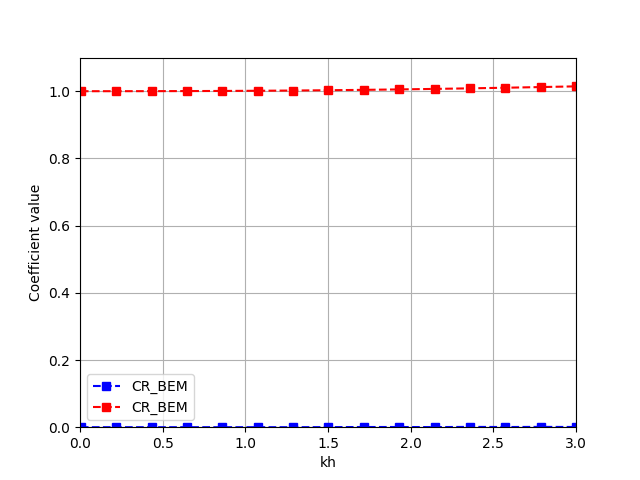

CR = [5.20341908e-08 7.96494105e-07 4.77197683e-06 1.33784627e-05
 3.50747883e-05 2.72781984e-05 5.77608053e-05 1.88755861e-04
 5.70710039e-04 5.90839943e-04 3.04646010e-04 9.30217006e-04
 5.32624586e-04 9.33019919e-04 6.41661241e-04]
CT = [1.00000002 1.00004058 1.00016564 1.00039442 1.00075439 1.00127532
 1.00198261 1.00289195 1.00400716 1.00532216 1.00682403 1.00849707
 1.0103284  1.01230525 1.01442082]


In [18]:
# Plot of the CR and CT vs kh
plt.figure(15)

plt.plot(kh, CR, 'b--s', label='CR_BEM')
plt.plot(kh, CT, 'r--s', label='CR_BEM')

plt.xlim([0, 3.00])
plt.ylim([0, 1.10])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("CR_CT.pdf")

# Optional: display the plot
plt.show()

print("CR =",CR)
print("CT =",CT)

**6.2 Organization of potentials and fluxes**

In [19]:
# Initialize array to store flux values (dphi/dn) across all boundaries
Fluxes_S = np.zeros_like(KCONEC[0:NCONEC,:], dtype=np.complex128)

In [20]:
# Define a vector to store all the velocity potentials
# FIX PHI, because Coef_S vector in multi-domain BEM contains Fluxes (dPHI/dn) as well
Coef_S_PHI = Coef_S.copy()

In [21]:
# Store the correct velocity potentials at the corresponding boundary interfaces
# phi_0 = phi_1 at interface
Coef_S_PHI = POTENTIAL_INTERFACE(Coef_S_PHI, Coef_S, STORE_NODE_R0_out, STORE_NODE_R1_in, N, 0, 1)

# phi_1 = phi_2 at interface
Coef_S_PHI = POTENTIAL_INTERFACE(Coef_S_PHI, Coef_S, STORE_NODE_R1_out, STORE_NODE_R2_in, N, 1, 2)

In [22]:
# Boundary conditions
# Inlet  dPHI/dn + ik PHI = 0
# Outlet dPHI/dn - ik PHI = 0
# FS     dPHI/dn - omega^2/g PHI = 0
# Bottom dPHI/dn = 0
# Imper  dPHI/dn = 0
# Front  dPHI/dn = 0
# Back   dPHI/dn = 0

# Interface PHI_0 = PHI_1,  dPHI_0/dn = dPHI_1/dn

# REGION 0
Fluxes_S = FLUXES_FREE_SURFACE(Coef_S, Fluxes_S, omega, gravity, NCONEC, REF_R0["FS"], KCONEC_0, N, NE, 0)
Fluxes_S = FLUXES_FAR_FIELD_IN(Coef_S, Fluxes_S, k, NCONEC, NORMAL, REF_R0["IN"], KCONEC_0, N, NE, 0)
# dPHI_0/dn = -dPHI_1/dn at interface
Fluxes_S = FLUXES_INTERFACE(Coef_S, Fluxes_S, STORE_NODE_R0_out, STORE_NODE_R1_in, N, NE, 0, 1)

# REGION 1
Fluxes_S = FLUXES_FREE_SURFACE(Coef_S, Fluxes_S, omega, gravity, NCONEC, REF_R1["FS"], KCONEC_1, N, NE, 1)
# dPHI_1/dn = -dPHI_2/dn at interface
Fluxes_S = FLUXES_INTERFACE(Coef_S, Fluxes_S, STORE_NODE_R1_out, STORE_NODE_R2_in, N, NE, 1, 2)

# REGION 2
Fluxes_S = FLUXES_FREE_SURFACE(Coef_S, Fluxes_S, omega, gravity, NCONEC, REF_R2["FS"], KCONEC_2, N, NE, 2)
Fluxes_S = FLUXES_FAR_FIELD_OUT(Coef_S, Fluxes_S, k, NCONEC, NORMAL, REF_R2["OUT"], KCONEC_2, N, NE, 2)

**6.3 Internal points**

In [23]:
# Calculation of internal velocity potentials
Max_X0 = max(MESH_0_POS[:,0])
Max_X1 = max(MESH_1_POS[:,0])
Max_X2 = max(MESH_2_POS[:,0])

dx = 0.01
dz = 0.10

CX_0 = np.linspace(0 + dx, Max_X0 - dx, 301)
CY_0 = np.zeros_like(CX_0)
CZ_0 = np.zeros_like(CX_0) - dz

DSOL_0 = INTERNAL_POINTS(Coef_S_PHI, Fluxes_S, DEPTH, CX_0, CY_0, CZ_0, MESH_0_POS, NCONEC, KCONEC_0, N, NE, 0)

CX_1 = np.linspace(Max_X0 + dx, Max_X1 - dx, 301)
CY_1 = np.zeros_like(CX_1)
CZ_1 = np.zeros_like(CX_1) - dz

DSOL_1 = INTERNAL_POINTS(Coef_S_PHI, Fluxes_S, DEPTH, CX_1, CY_1, CZ_1, MESH_1_POS, NCONEC, KCONEC_1, N, NE, 1)

CX_2 = np.linspace(Max_X1 + dx, Max_X2 - dx, 301)
CY_2 = np.zeros_like(CX_2)
CZ_2 = np.zeros_like(CX_2) - dz

DSOL_2 = INTERNAL_POINTS(Coef_S_PHI, Fluxes_S, DEPTH, CX_2, CY_2, CZ_2, MESH_2_POS, NCONEC, KCONEC_2, N, NE, 2)

ETA_IP_0 = np.real((1j * rho * omega) * DSOL_0  * np.exp(-1j * omega * np.pi / omega))
ETA_IP_1 = np.real((1j * rho * omega) * DSOL_1  * np.exp(-1j * omega * np.pi / omega))
ETA_IP_2 = np.real((1j * rho * omega) * DSOL_2  * np.exp(-1j * omega * np.pi / omega))

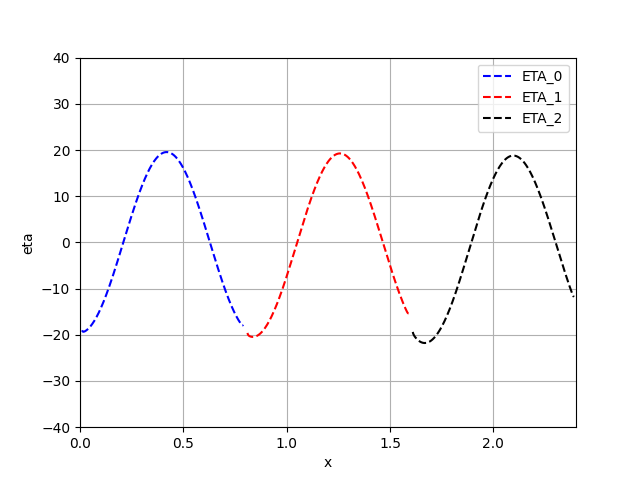

In [24]:
# Plot of the dynamic pressure amplitude
plt.figure()

plt.plot(CX_0, ETA_IP_0, 'b--', label='ETA_0')
plt.plot(CX_1, ETA_IP_1, 'r--', label='ETA_1')
plt.plot(CX_2, ETA_IP_2, 'k--', label='ETA_2')

plt.xlim([0, Max_X2])
plt.ylim([-40, 40])

plt.xlabel('x')
plt.ylabel('eta')

plt.legend()
plt.grid(True)

# Optional: display the plot
plt.show()

**6.4 Free surface**

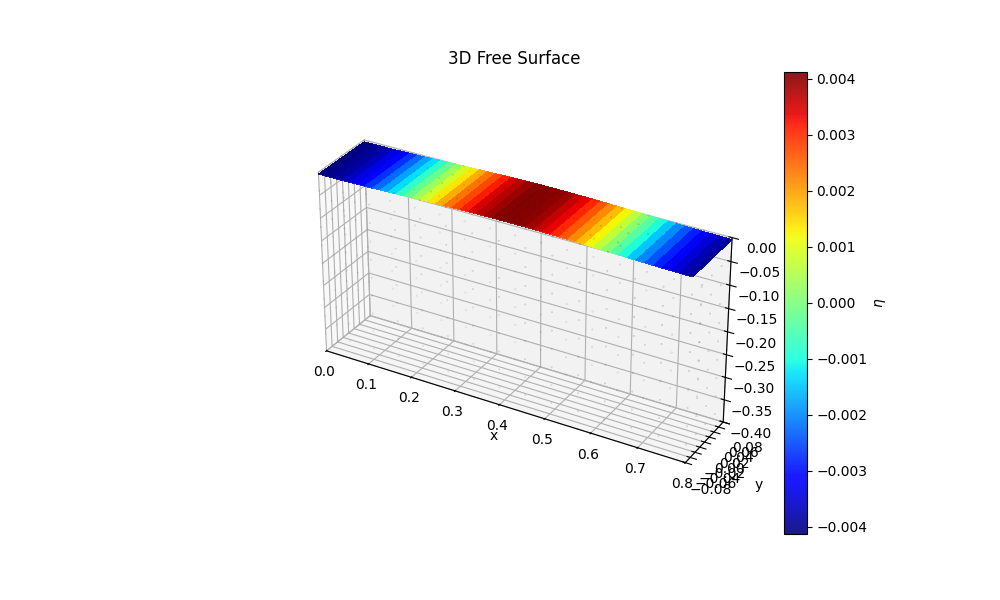

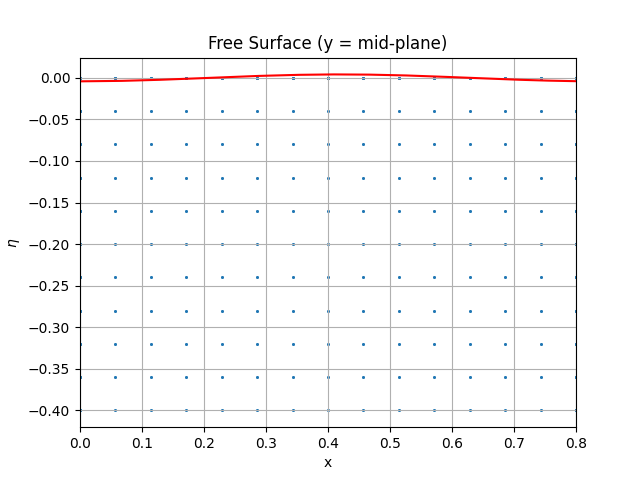

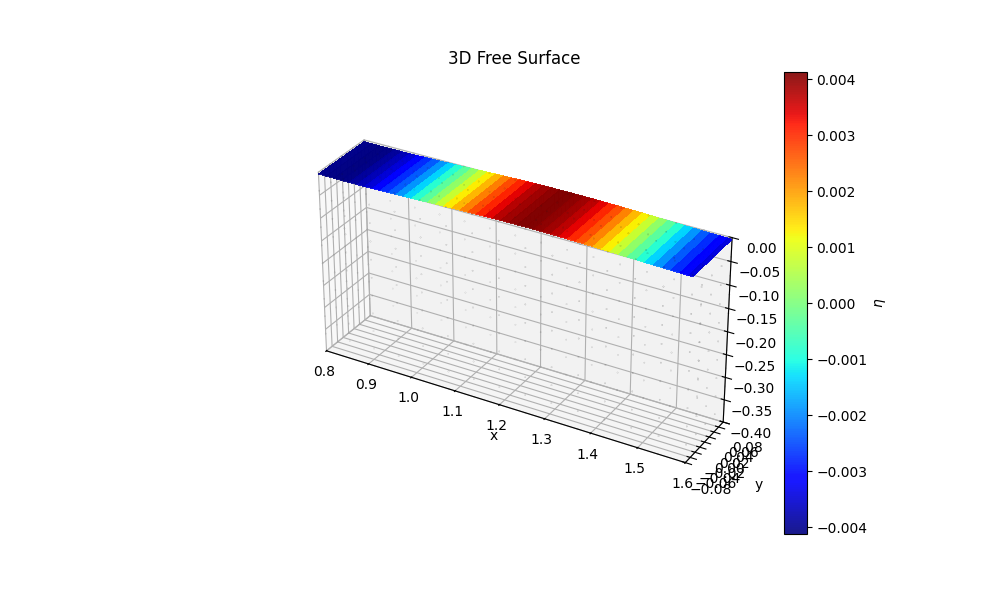

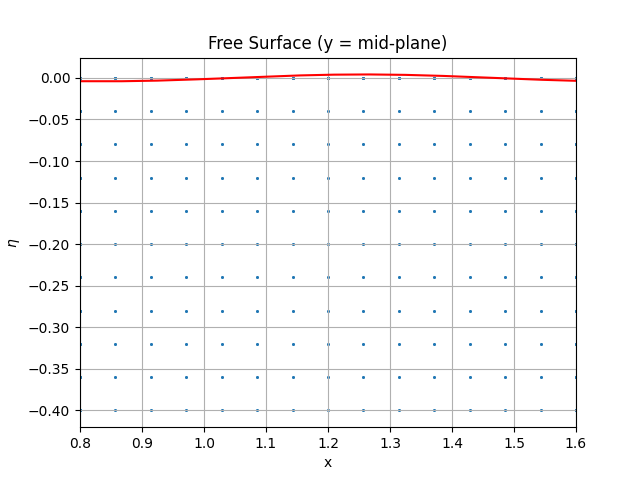

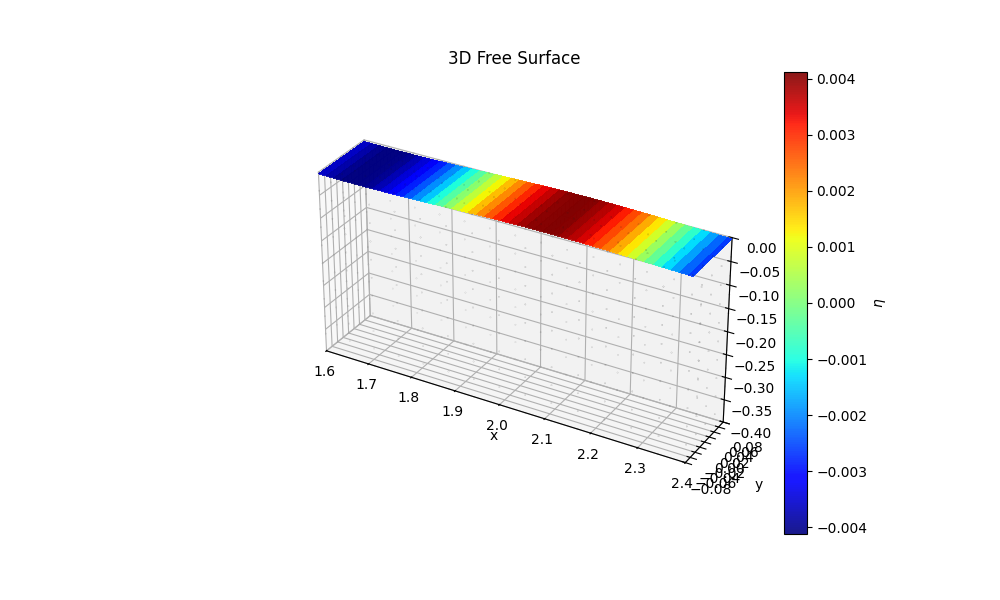

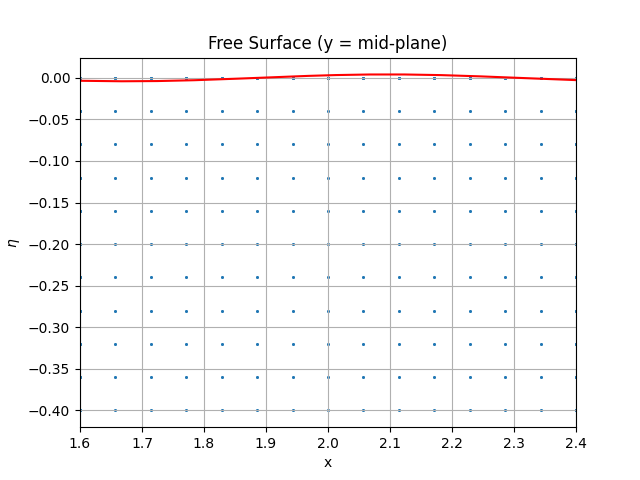

In [25]:
# Free surface plot
PHI_FS_0 = VISUAL_FREE_SURFACE(Coef_S_PHI, k, omega, gravity, Wave_height, DEPTH, NCONEC, REF_R0["FS"], MESH_0_POS, MESH_0_POS, KCONEC, N, NE, 0)
PHI_FS_1 = VISUAL_FREE_SURFACE(Coef_S_PHI, k, omega, gravity, Wave_height, DEPTH, NCONEC, REF_R1["FS"], MESH_1_POS, MESH_1_POS, KCONEC, N, NE, 1)
PHI_FS_2 = VISUAL_FREE_SURFACE(Coef_S_PHI, k, omega, gravity, Wave_height, DEPTH, NCONEC, REF_R2["FS"], MESH_2_POS, MESH_2_POS, KCONEC, N, NE, 2)